In [4]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Literal
from pydantic import BaseModel,Field
import operator

In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

from langchain_groq import ChatGroq

model = ChatGroq( model="openai/gpt-oss-20b", api_key=os.environ.get("GROQ_API_KEY"))

e:\Langchain\langchain-env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
class SentimentState(TypedDict):
    sentiment: Literal["positive","negative","neutral"] = Field(description="The sentiment of the text")
    review: str = Field(description="The original text that was analyzed")
    response: str = Field(description="The final response to the user")

In [6]:
structured_model = model.with_structured_output(SentimentState)

In [7]:
prompt = "What is the sentiment of the following text: 'I love this product!'"

structured_model.invoke(prompt)

{'sentiment': 'positive'}

In [13]:
# negative sentiment
prompt = "What is the sentiment of the following text: 'I hate this product!'"
structured_model.invoke(prompt).get("sentiment")

'negative'

In [17]:
def analyze_sentiment(state:SentimentState):

    review = state["review"]

    prompt = f"""What is the sentiment of the following text: '{review}'? Please classify the sentiment as either positive, negative, or neutral."""

    response = structured_model.invoke(prompt).get("sentiment")

    return {"sentiment": response}


def positive_sentiment(state: SentimentState):

    review = state["review"]

    prompt = f"""The following review was classified as having a positive sentiment: '{review}'. Please provide a response to the user that acknowledges their positive sentiment and encourages them to continue using the product."""

    response = model.invoke(prompt)

    return {"response": response}

def negative_sentiment(state: SentimentState):

    review = state["review"]

    prompt = f"""The following review was classified as having a negative sentiment: '{review}'. Please provide a response to the user that acknowledges their negative sentiment and encourages them to provide more feedback on how we can improve."""

    response = model.invoke(prompt)

    return {"response": response}

def neutral_sentiment(state: SentimentState):
    review = state["review"]

    prompt = f"""The following review was classified as having a neutral sentiment: '{review}'. Please provide a response to the user that acknowledges their feedback and encourages them to provide more details on their experience."""

    response = model.invoke(prompt)

    return {"response": response}


def check_sentiment(state:SentimentState) -> Literal["positive_sentiment","negative_sentiment","neutral_sentiment"]:

    sentiment = state["sentiment"]

    if sentiment == "positive":
        return "positive_sentiment"
    elif sentiment == "negative":
        return "negative_sentiment"
    else:
        return "neutral_sentiment"



In [20]:
graph = StateGraph(SentimentState)
graph.add_node("analyze_sentiment", analyze_sentiment)
graph.add_node("positive_sentiment", positive_sentiment)
graph.add_node("negative_sentiment", negative_sentiment)
graph.add_node("neutral_sentiment", neutral_sentiment)

graph.add_edge(START, "analyze_sentiment")
graph.add_conditional_edges("analyze_sentiment", check_sentiment)

graph.add_edge("positive_sentiment", END)
graph.add_edge("negative_sentiment", END)
graph.add_edge("neutral_sentiment", END)

workflow = graph.compile()



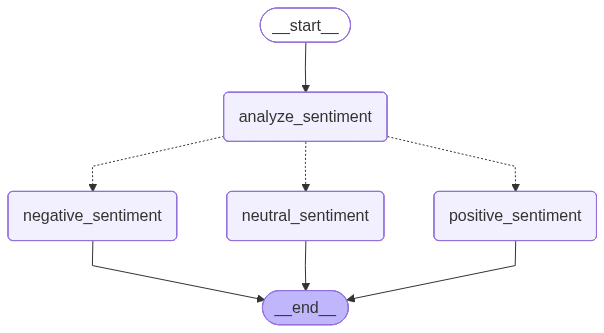

In [21]:
workflow

In [ ]:
initial_state = {
    "review": "I love this product!"
}

workflow.invoke(initial_state)

{'sentiment': 'positive',
 'review': 'I love this product!',
 'response': AIMessage(content="Thank you for sharing your enthusiasm! We're thrilled to hear that you love the product. Keep enjoying it, and feel free to let us know if there’s anything else that could make your experience even better. Your feedback helps us keep delivering the best possible experience!", additional_kwargs={'reasoning_content': 'We need to respond acknowledging positive sentiment, encouraging continued use. The user says: "The following review was classified as having a positive sentiment: \'I love this product!\'. Please provide a response to the user that acknowledges their positive sentiment and encourages them to continue using the product."\n\nWe need to respond to the user. Should be a friendly, encouraging tone. Acknowledge that the review is positive, say thanks, encourage them to keep using, maybe ask for feedback. Provide a response. That\'s all.'}, response_metadata={'token_usage': {'completion_t

In [23]:
# hate speech example
initial_state = {
    "review": " The twitter user @example is a terrible person and I hate them!"
}

workflow.invoke(initial_state)

{'sentiment': 'negative',
 'review': ' The twitter user @example is a terrible person and I hate them!',
 'response': AIMessage(content='I’m really sorry you’re feeling this way. We’d love to understand more about what happened and how we can make things better for you. Could you share a bit more detail about the issue or any suggestions you have? Your feedback helps us improve.', additional_kwargs={'reasoning_content': 'We need to respond acknowledging negative sentiment, encouraging feedback. The user says: "The twitter user @example is a terrible person and I hate them!" The review was classified as negative sentiment. We need to respond to the user acknowledging their negative sentiment and encouraging them to provide more feedback on how we can improve. It\'s a response to the user, so we need to respond empathetically, acknowledging their feelings, encouraging them to give more feedback. We need to not mention classification or system details. Just respond with empathy, encourage

In [24]:
# neutral sentiment example
initial_state = {
    "review": "The product is okay, it works but has some issues."
}

workflow.invoke(initial_state)

{'sentiment': 'neutral',
 'review': 'The product is okay, it works but has some issues.',
 'response': AIMessage(content='Thank you for sharing your thoughts! We’re glad to hear the product is working for you, but we’d love to understand what issues you encountered. Could you tell us a bit more about the challenges you faced or any specific features that didn’t meet your expectations? Your feedback helps us improve and make the experience better for everyone.', additional_kwargs={'reasoning_content': 'We need to respond acknowledging feedback, encourage more details. The user says the review was classified as neutral. We need to respond to user. Probably ask them to elaborate. Provide empathy. Provide a friendly tone.'}, response_metadata={'token_usage': {'completion_tokens': 118, 'prompt_tokens': 117, 'total_tokens': 235, 'completion_time': 0.122336826, 'completion_tokens_details': {'reasoning_tokens': 43}, 'prompt_time': 0.008127826, 'prompt_tokens_details': None, 'queue_time': 0.043